<a href="https://colab.research.google.com/github/HeshanNavindu-7/oilspill-reseach/blob/main/final_CSV_dataset_creation_code_trajectory_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install requests -q

In [2]:
import os
import cv2
import math
import json
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime, timezone, timedelta
from getpass import getpass

import tensorflow as tf
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ==============================
# PATH CONFIGURATION
# ==============================

PROJECT_PATH = Path("/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset")
PROJECT_PATH.mkdir(parents=True, exist_ok=True)

# Folder with images you want to use for trajectory dataset
IMAGE_FOLDER = Path("/content/drive/MyDrive/Oil Spill/Dataset Cretaion /trajectory_input_images")

# Your saved segmentation model
SEG_MODEL_PATH = "/content/drive/MyDrive/Oil Spill/edge_project/models/edge_unet_stage1_best.keras"

# Outputs
MASK_OUTPUT_DIR = PROJECT_PATH / "predicted_masks"
MASK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_API_DIR = PROJECT_PATH / "stormglass_raw_api"
RAW_API_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = PROJECT_PATH / "oil_spill_trajectory_dataset_with_api.csv"

# Change this if your segmentation model trained with another size
IMG_SIZE = 256

print("Project path:", PROJECT_PATH)
print("Image folder:", IMAGE_FOLDER)
print("Model path:", SEG_MODEL_PATH)
print("Output CSV:", OUTPUT_CSV)

Project path: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset
Image folder: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /trajectory_input_images
Model path: /content/drive/MyDrive/Oil Spill/edge_project/models/edge_unet_stage1_best.keras
Output CSV: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/oil_spill_trajectory_dataset_with_api.csv


In [5]:
image_files = sorted([
    p for p in IMAGE_FOLDER.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("Total images found:", len(image_files))

# Start with 10 images first
image_files = image_files[:10]

print("Selected images:", len(image_files))

for img in image_files:
    print(img.name)

Total images found: 13
Selected images: 10
2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg
3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg
4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg.rf.9a445348f573c8ae3a08f2a12311548c.jpg
5d13daec4d808-image_jpg.rf.1c589b9aff396953be0ec3e1b93e6a38.jpg
5d97cf24077e_jpg.rf.62caf0ef9fb2f8fd3d72366def794aed.jpg
5fd2d380-7151-4754-98dc-9d1097556ad2_jpg.rf.188cb43ecc0b11706b7cd0f57873f640.jpg
9c9cf8c86d88a0f62bf22ba6931467bd_jpg.rf.2f1a427fbd9ac51f7ff167d070a71fac.jpg
C-130_support_oil_spill_cleanup.jpg
Defense.gov_photo_essay_100506-N-6436W-023.jpg
Skimming_Oil_in_Gulf_of_Mexico.jpg


In [6]:
seg_model = tf.keras.models.load_model(SEG_MODEL_PATH, compile=False)

print("Segmentation model loaded successfully")
print("Input shape:", seg_model.input_shape)
print("Output shape:", seg_model.output_shape)

Segmentation model loaded successfully
Input shape: (None, 160, 160, 3)
Output shape: (None, 160, 160, 1)


In [7]:
STORMGLASS_API_KEY = getpass("Enter your StormGlass API key: ")

Enter your StormGlass API key: ··········


In [8]:
def preprocess_image_for_segmentation(image_path, img_size=256):
    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img_rgb.shape[:2]

    resized = cv2.resize(img_rgb, (img_size, img_size))
    normalized = resized / 255.0

    input_tensor = np.expand_dims(normalized, axis=0).astype(np.float32)

    return img_rgb, input_tensor, original_h, original_w

In [9]:
print("Model input shape:", seg_model.input_shape)
print("Model output shape:", seg_model.output_shape)

Model input shape: (None, 160, 160, 3)
Model output shape: (None, 160, 160, 1)


In [10]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

IMAGE_FOLDER = Path("/content/drive/MyDrive/Oil Spill/Dataset Cretaion /trajectory_input_images")

MASK_OUTPUT_DIR = PROJECT_PATH / "predicted_masks"
MASK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 160
MASK_THRESHOLD = 0.05

image_files = sorted([
    p for p in IMAGE_FOLDER.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

print("Images found:", len(image_files))

Images found: 13


In [11]:
def preprocess_image_for_segmentation(image_path, img_size=160):
    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img_rgb.shape[:2]

    resized = cv2.resize(img_rgb, (img_size, img_size))
    normalized = resized / 255.0

    input_tensor = np.expand_dims(normalized, axis=0).astype(np.float32)

    return img_rgb, input_tensor, original_h, original_w

In [12]:
def convert_image_to_mask(image_path, model, img_size=160, threshold=0.5):
    original_img, input_tensor, original_h, original_w = preprocess_image_for_segmentation(
        image_path,
        img_size
    )

    pred = model.predict(input_tensor, verbose=0)
    pred_mask = pred[0]

    if pred_mask.ndim == 3:
        pred_mask = pred_mask[:, :, 0]

    binary_mask = (pred_mask >= threshold).astype(np.uint8)

    # resize predicted mask back to original image size
    binary_mask_original = cv2.resize(
        binary_mask,
        (original_w, original_h),
        interpolation=cv2.INTER_NEAREST
    )

    return original_img, binary_mask_original, pred_mask

In [13]:
mask_records = []

for image_path in image_files:
    print("Processing:", image_path.name)

    original_img, binary_mask, raw_mask = convert_image_to_mask(
        image_path=image_path,
        model=seg_model,
        img_size=IMG_SIZE,
        threshold=MASK_THRESHOLD
    )

    mask_file_name = image_path.stem + "_predicted_mask.png"
    mask_path = MASK_OUTPUT_DIR / mask_file_name

    mask_to_save = (binary_mask * 255).astype(np.uint8)
    cv2.imwrite(str(mask_path), mask_to_save)

    area_pixels = int(np.sum(binary_mask > 0))
    total_pixels = binary_mask.shape[0] * binary_mask.shape[1]
    area_ratio = area_pixels / total_pixels

    oil_status = "oil_spill_detected" if area_ratio >= 0.001 else "no_oil_spill_detected"

    mask_records.append({
        "image_name": image_path.name,
        "image_path": str(image_path),
        "mask_name": mask_file_name,
        "mask_path": str(mask_path),
        "oil_status": oil_status,
        "area_pixels": area_pixels,
        "area_ratio": area_ratio
    })

    print("Saved mask:", mask_path)
    print("Oil status:", oil_status)
    print("Area ratio:", area_ratio)

mask_df = pd.DataFrame(mask_records)
display(mask_df)

Processing: 2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg
Saved mask: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/predicted_masks/2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd_predicted_mask.png
Oil status: oil_spill_detected
Area ratio: 0.77796875
Processing: 3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg
Saved mask: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/predicted_masks/3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a_predicted_mask.png
Oil status: oil_spill_detected
Area ratio: 0.076328125
Processing: 4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg.rf.9a445348f573c8ae3a08f2a12311548c.jpg
Saved mask: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/predicted_masks/4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg.rf.9a445348f573c8ae3a08f2a12311548c_predicted_mask.png
Oil status: oil_spill_detected
Area ratio: 0.737109375
Processing: 5d13daec4d808-image_jpg.rf.1c589b9aff396953be0ec3e1b93e6a38.jpg
Saved mask: /content/drive/My

,image_name,image_path,mask_name,mask_path,oil_status,area_pixels,area_ratio
0,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd_pred...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,318656,0.777969
1,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a_pred...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,31264,0.076328
2,4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg....,/content/drive/MyDrive/Oil Spill/Dataset Creta...,4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg....,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,301920,0.737109
3,5d13daec4d808-image_jpg.rf.1c589b9aff396953be0...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,5d13daec4d808-image_jpg.rf.1c589b9aff396953be0...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,103504,0.252695
4,5d97cf24077e_jpg.rf.62caf0ef9fb2f8fd3d72366def...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,5d97cf24077e_jpg.rf.62caf0ef9fb2f8fd3d72366def...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,112800,0.275391
5,5fd2d380-7151-4754-98dc-9d1097556ad2_jpg.rf.18...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,5fd2d380-7151-4754-98dc-9d1097556ad2_jpg.rf.18...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,6944,0.016953
6,9c9cf8c86d88a0f62bf22ba6931467bd_jpg.rf.2f1a42...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,9c9cf8c86d88a0f62bf22ba6931467bd_jpg.rf.2f1a42...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,14080,0.034375
7,C-130_support_oil_spill_cleanup.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,C-130_support_oil_spill_cleanup_predicted_mask...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,170833,0.058231
8,Defense.gov_photo_essay_100506-N-6436W-023.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,Defense.gov_photo_essay_100506-N-6436W-023_pre...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,8584,0.191821
9,Skimming_Oil_in_Gulf_of_Mexico.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,Skimming_Oil_in_Gulf_of_Mexico_predicted_mask.png,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,6305749,0.742487


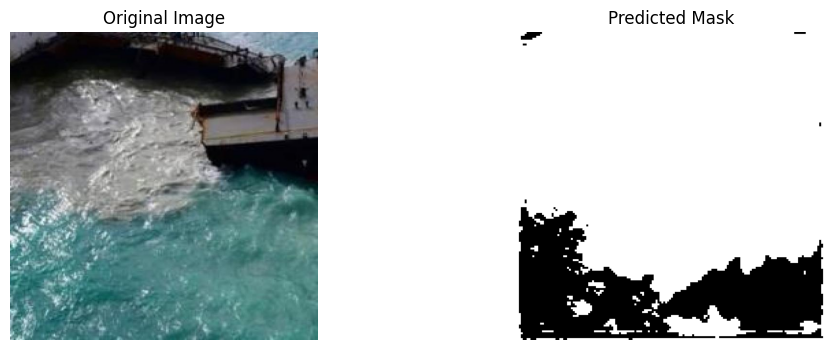

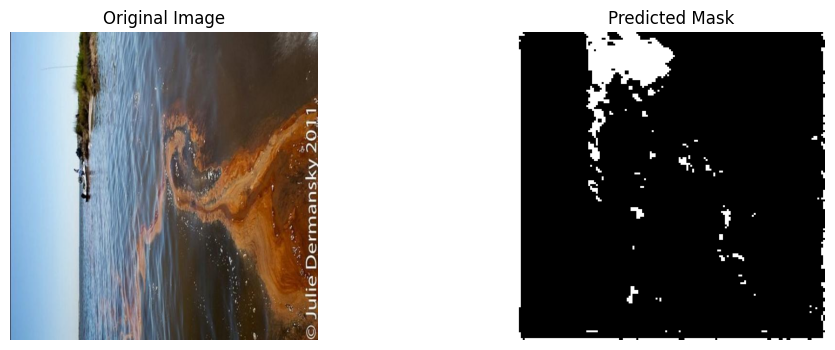

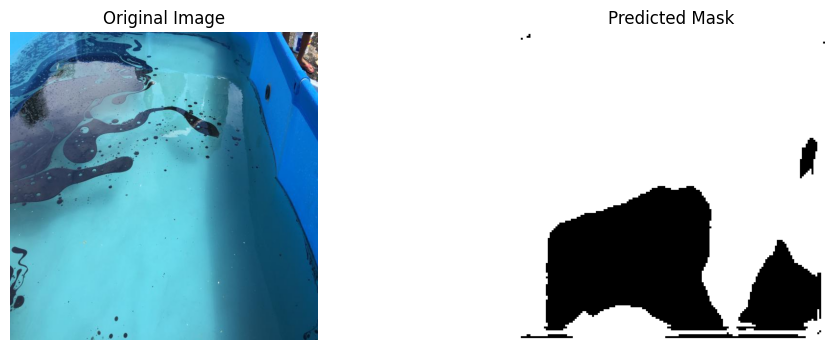

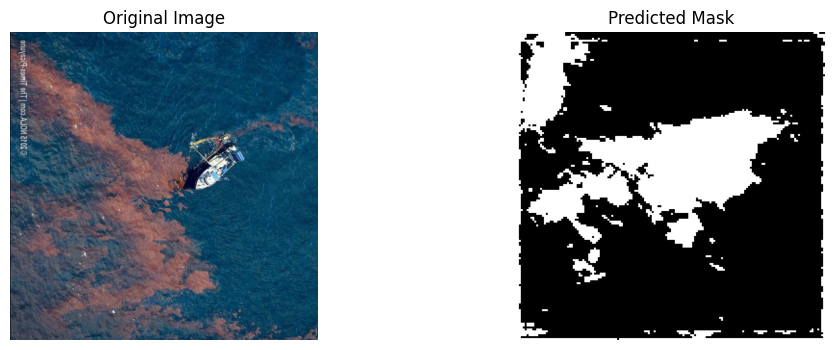

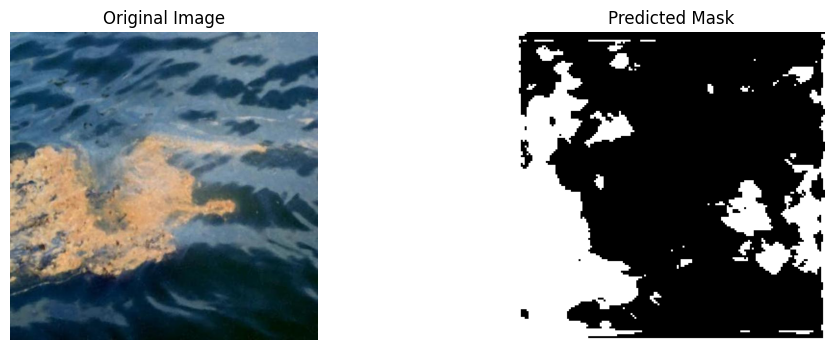

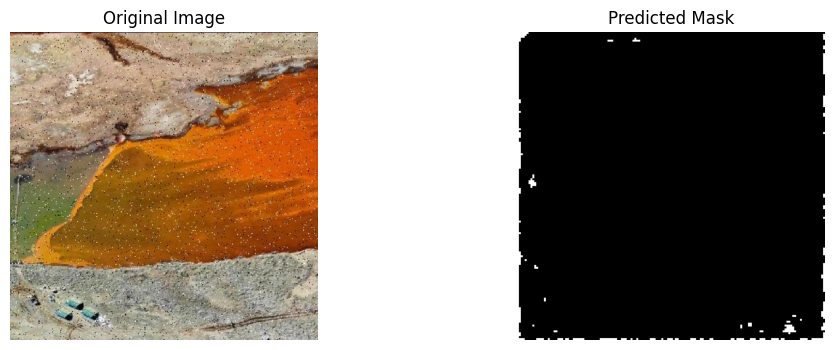

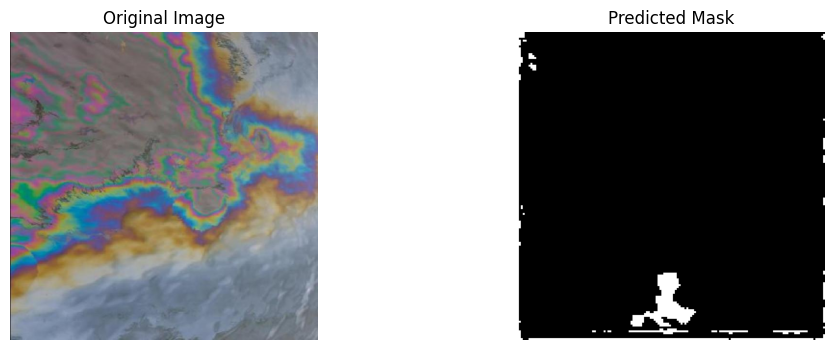

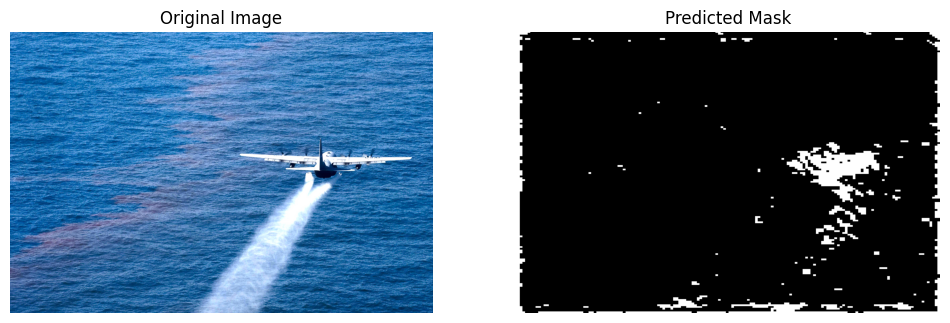

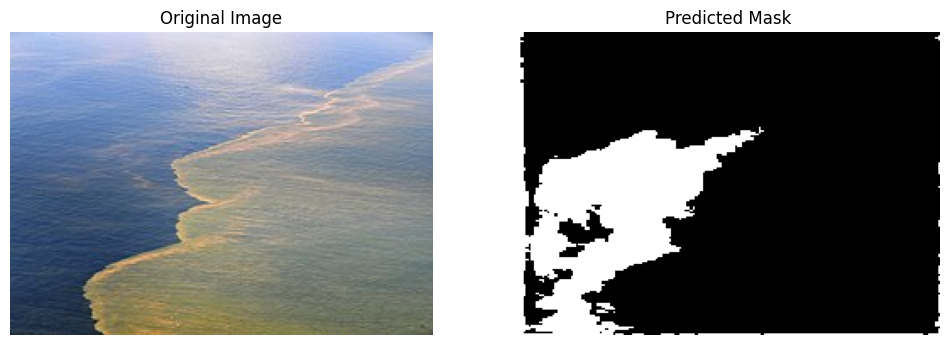

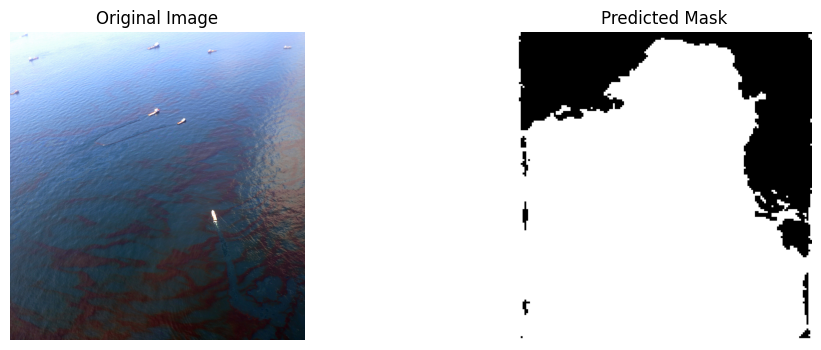

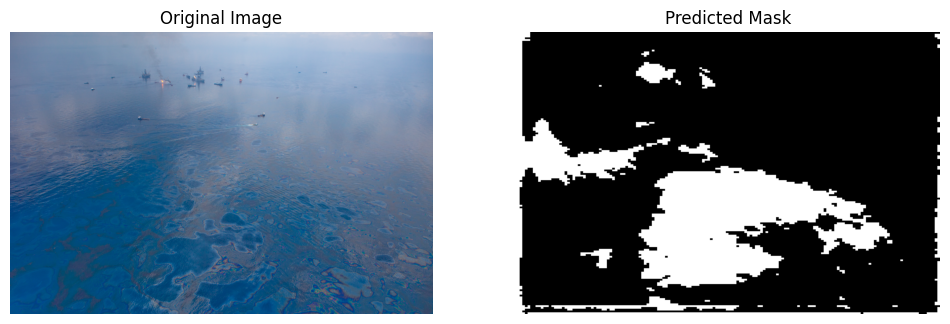

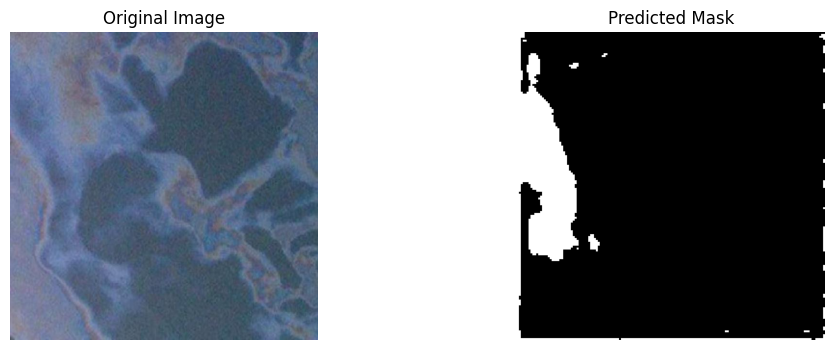

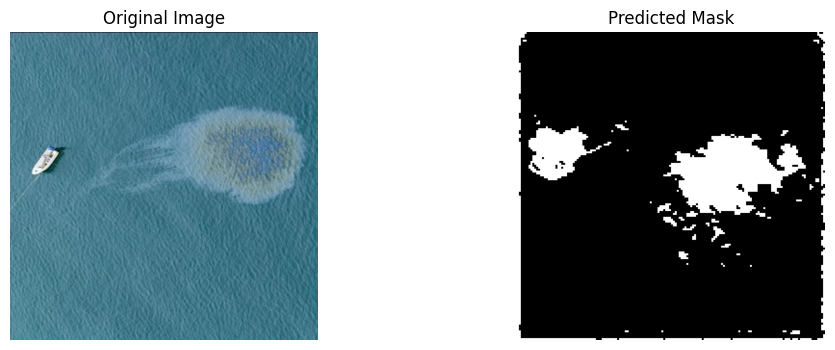

In [14]:
for i, row in mask_df.iterrows():
    image_path = row["image_path"]
    mask_path = row["mask_path"]

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

In [15]:
current_time = datetime.now(timezone.utc).replace(minute=0, second=0, microsecond=0)

# Base coordinates for the Gulf of Mexico (where previous examples were set)
base_lat = 28.7366
base_lon = -88.3872

# Define a small range for random variation (e.g., +/- 0.05 degrees)
lat_variation = 0.1
lon_variation = 0.1

manual_scenarios = pd.DataFrame([
    {
        "image_name": "C-130_support_oil_spill_cleanup.jpg",
        "scene_lat": base_lat + np.random.uniform(-lat_variation, lat_variation),
        "scene_lon": base_lon + np.random.uniform(-lon_variation, lon_variation),
        "scene_datetime_utc": (current_time).isoformat(sep=' ', timespec='minutes')
    },
    {
        "image_name": "Defense.gov_photo_essay_100506-N-6436W-023.jpg",
        "scene_lat": base_lat + np.random.uniform(-lat_variation, lat_variation),
        "scene_lon": base_lon + np.random.uniform(-lon_variation, lon_variation),
        "scene_datetime_utc": (current_time + timedelta(hours=1)).isoformat(sep=' ', timespec='minutes')
    },
    {
        "image_name": "Skimming_Oil_in_Gulf_of_Mexico.jpg",
        "scene_lat": base_lat + np.random.uniform(-lat_variation, lat_variation),
        "scene_lon": base_lon + np.random.uniform(-lon_variation, lon_variation),
        "scene_datetime_utc": (current_time + timedelta(hours=2)).isoformat(sep=' ', timespec='minutes')
    },
    {
        "image_name": "Warzone_in_Gulf_of_Mexico.jpg",
        "scene_lat": base_lat + np.random.uniform(-lat_variation, lat_variation),
        "scene_lon": base_lon + np.random.uniform(-lon_variation, lon_variation),
        "scene_datetime_utc": (current_time + timedelta(hours=3)).isoformat(sep=' ', timespec='minutes')
    }
])

display(manual_scenarios)

,image_name,scene_lat,scene_lon,scene_datetime_utc
0,C-130_support_oil_spill_cleanup.jpg,28.645718,-88.366253,2026-04-18 12:00+00:00
1,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.690883,-88.299739,2026-04-18 13:00+00:00
2,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.679368,-88.436387,2026-04-18 14:00+00:00
3,Warzone_in_Gulf_of_Mexico.jpg,28.641762,-88.480151,2026-04-18 15:00+00:00


In [16]:
manual_scenarios["scene_datetime_utc"] = pd.to_datetime(
    manual_scenarios["scene_datetime_utc"],
    utc=True
)

display(manual_scenarios)

,image_name,scene_lat,scene_lon,scene_datetime_utc
0,C-130_support_oil_spill_cleanup.jpg,28.645718,-88.366253,2026-04-18 12:00:00+00:00
1,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.690883,-88.299739,2026-04-18 13:00:00+00:00
2,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.679368,-88.436387,2026-04-18 14:00:00+00:00
3,Warzone_in_Gulf_of_Mexico.jpg,28.641762,-88.480151,2026-04-18 15:00:00+00:00


In [17]:
trajectory_input_df = mask_df.merge(
    manual_scenarios,
    on="image_name",
    how="left"
)

trajectory_input_df["scenario_id"] = range(1, len(trajectory_input_df) + 1)

display(trajectory_input_df)

,image_name,image_path,mask_name,mask_path,oil_status,area_pixels,area_ratio,scene_lat,scene_lon,scene_datetime_utc,scenario_id
0,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd_pred...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,318656,0.777969,NaN,NaN,NaT,1
1,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a_pred...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,31264,0.076328,NaN,NaN,NaT,2
2,4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg....,/content/drive/MyDrive/Oil Spill/Dataset Creta...,4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg....,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,301920,0.737109,NaN,NaN,NaT,3
3,5d13daec4d808-image_jpg.rf.1c589b9aff396953be0...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,5d13daec4d808-image_jpg.rf.1c589b9aff396953be0...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,103504,0.252695,NaN,NaN,NaT,4
4,5d97cf24077e_jpg.rf.62caf0ef9fb2f8fd3d72366def...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,5d97cf24077e_jpg.rf.62caf0ef9fb2f8fd3d72366def...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,112800,0.275391,NaN,NaN,NaT,5
5,5fd2d380-7151-4754-98dc-9d1097556ad2_jpg.rf.18...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,5fd2d380-7151-4754-98dc-9d1097556ad2_jpg.rf.18...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,6944,0.016953,NaN,NaN,NaT,6
6,9c9cf8c86d88a0f62bf22ba6931467bd_jpg.rf.2f1a42...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,9c9cf8c86d88a0f62bf22ba6931467bd_jpg.rf.2f1a42...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,14080,0.034375,NaN,NaN,NaT,7
7,C-130_support_oil_spill_cleanup.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,C-130_support_oil_spill_cleanup_predicted_mask...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,170833,0.058231,28.645718,-88.366253,2026-04-18 12:00:00+00:00,8
8,Defense.gov_photo_essay_100506-N-6436W-023.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,Defense.gov_photo_essay_100506-N-6436W-023_pre...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,8584,0.191821,28.690883,-88.299739,2026-04-18 13:00:00+00:00,9
9,Skimming_Oil_in_Gulf_of_Mexico.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,Skimming_Oil_in_Gulf_of_Mexico_predicted_mask.png,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,6305749,0.742487,28.679368,-88.436387,2026-04-18 14:00:00+00:00,10


In [18]:
display(trajectory_input_df[[
    "scenario_id",
    "image_name",
    "oil_status",
    "area_ratio",
    "scene_lat",
    "scene_lon",
    "scene_datetime_utc"
]])

,scenario_id,image_name,oil_status,area_ratio,scene_lat,scene_lon,scene_datetime_utc
0,1,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,oil_spill_detected,0.777969,NaN,NaN,NaT
1,2,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg,oil_spill_detected,0.076328,NaN,NaN,NaT
2,3,4E355A0E-634A-429B-B9B2-1164D60D0ED6_jpeg_jpg....,oil_spill_detected,0.737109,NaN,NaN,NaT
3,4,5d13daec4d808-image_jpg.rf.1c589b9aff396953be0...,oil_spill_detected,0.252695,NaN,NaN,NaT
4,5,5d97cf24077e_jpg.rf.62caf0ef9fb2f8fd3d72366def...,oil_spill_detected,0.275391,NaN,NaN,NaT
5,6,5fd2d380-7151-4754-98dc-9d1097556ad2_jpg.rf.18...,oil_spill_detected,0.016953,NaN,NaN,NaT
6,7,9c9cf8c86d88a0f62bf22ba6931467bd_jpg.rf.2f1a42...,oil_spill_detected,0.034375,NaN,NaN,NaT
7,8,C-130_support_oil_spill_cleanup.jpg,oil_spill_detected,0.058231,28.645718,-88.366253,2026-04-18 12:00:00+00:00
8,9,Defense.gov_photo_essay_100506-N-6436W-023.jpg,oil_spill_detected,0.191821,28.690883,-88.299739,2026-04-18 13:00:00+00:00
9,10,Skimming_Oil_in_Gulf_of_Mexico.jpg,oil_spill_detected,0.742487,28.679368,-88.436387,2026-04-18 14:00:00+00:00


In [19]:
trajectory_input_df = manual_scenarios.copy()

In [20]:
trajectory_input_df["scene_datetime_utc"] = pd.to_datetime(
    trajectory_input_df["scene_datetime_utc"],
    utc=True
)

display(trajectory_input_df)

,image_name,scene_lat,scene_lon,scene_datetime_utc
0,C-130_support_oil_spill_cleanup.jpg,28.645718,-88.366253,2026-04-18 12:00:00+00:00
1,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.690883,-88.299739,2026-04-18 13:00:00+00:00
2,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.679368,-88.436387,2026-04-18 14:00:00+00:00
3,Warzone_in_Gulf_of_Mexico.jpg,28.641762,-88.480151,2026-04-18 15:00:00+00:00


In [21]:
print(trajectory_input_df.columns)
display(trajectory_input_df.head())

Index(['image_name', 'scene_lat', 'scene_lon', 'scene_datetime_utc'], dtype='object')


,image_name,scene_lat,scene_lon,scene_datetime_utc
0,C-130_support_oil_spill_cleanup.jpg,28.645718,-88.366253,2026-04-18 12:00:00+00:00
1,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.690883,-88.299739,2026-04-18 13:00:00+00:00
2,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.679368,-88.436387,2026-04-18 14:00:00+00:00
3,Warzone_in_Gulf_of_Mexico.jpg,28.641762,-88.480151,2026-04-18 15:00:00+00:00


In [22]:
# Make sure scenario_id exists as a real column
trajectory_input_df = trajectory_input_df.reset_index(drop=True)

if "scenario_id" not in trajectory_input_df.columns:
    trajectory_input_df.insert(0, "scenario_id", range(1, len(trajectory_input_df) + 1))

# Make sure date column is datetime UTC
trajectory_input_df["scene_datetime_utc"] = pd.to_datetime(
    trajectory_input_df["scene_datetime_utc"],
    utc=True
)

display(trajectory_input_df)
print(trajectory_input_df.columns)

,scenario_id,image_name,scene_lat,scene_lon,scene_datetime_utc
0,1,C-130_support_oil_spill_cleanup.jpg,28.645718,-88.366253,2026-04-18 12:00:00+00:00
1,2,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.690883,-88.299739,2026-04-18 13:00:00+00:00
2,3,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.679368,-88.436387,2026-04-18 14:00:00+00:00
3,4,Warzone_in_Gulf_of_Mexico.jpg,28.641762,-88.480151,2026-04-18 15:00:00+00:00


Index(['scenario_id', 'image_name', 'scene_lat', 'scene_lon',
       'scene_datetime_utc'],
      dtype='object')


In [23]:
all_records = []

for idx, row in trajectory_input_df.iterrows():
    print("=" * 80)
    print(f"Processing scenario {row['scenario_id']}: {row['image_name']}")

    scenario_id = int(row["scenario_id"])
    scene_lat = float(row["scene_lat"])
    scene_lon = float(row["scene_lon"])
    scene_datetime_utc = row["scene_datetime_utc"].to_pydatetime()

    try:
        cache_file = RAW_API_DIR / f"scenario_{scenario_id}_stormglass.json"

        # 1. Get wind/wave/current/swell data from API
        stormglass_raw = get_stormglass_data(
            lat=scene_lat,
            lon=scene_lon,
            selected_datetime_utc=scene_datetime_utc,
            api_key=STORMGLASS_API_KEY,
            cache_file=cache_file
        )

        marine = parse_stormglass_response(stormglass_raw)

        # 2. Estimate next location
        movement = estimate_next_location(
            lat=scene_lat,
            lon=scene_lon,
            marine=marine,
            dt_seconds=3600
        )

        # 3. Save final record
        record = {
            "scenario_id": scenario_id,
            "image_name": row["image_name"],
            "oil_status": row["oil_status"],
            "area_ratio": row["area_ratio"],

            "scene_lat": scene_lat,
            "scene_lon": scene_lon,
            "scene_datetime_utc": scene_datetime_utc.isoformat(),

            "api_time": marine["api_time"],

            "wind_speed": marine["wind_speed"],
            "wind_direction": marine["wind_direction"],

            "current_speed": marine["current_speed"],
            "current_direction": marine["current_direction"],

            "wave_height": marine["wave_height"],
            "wave_direction": marine["wave_direction"],
            "wave_period": marine["wave_period"],

            "swell_height": marine["swell_height"],
            "swell_direction": marine["swell_direction"],
            "swell_period": marine["swell_period"],

            "secondary_swell_height": marine["secondary_swell_height"],
            "secondary_swell_direction": marine["secondary_swell_direction"],
            "secondary_swell_period": marine["secondary_swell_period"],

            "wind_wave_height": marine["wind_wave_height"],
            "wind_wave_direction": marine["wind_wave_direction"],
            "wind_wave_period": marine["wind_wave_period"],

            "wind_u": movement["wind_u"],
            "wind_v": movement["wind_v"],

            "current_u": movement["current_u"],
            "current_v": movement["current_v"],

            "wave_u": movement["wave_u"],
            "wave_v": movement["wave_v"],

            "swell_u": movement["swell_u"],
            "swell_v": movement["swell_v"],

            "total_drift_u": movement["total_drift_u"],
            "total_drift_v": movement["total_drift_v"],

            "east_movement_m": movement["east_movement_m"],
            "north_movement_m": movement["north_movement_m"],

            "next_lat": movement["next_lat"],
            "next_lon": movement["next_lon"]
        }

        all_records.append(record)

        print("API time:", marine["api_time"])
        print("Wind speed:", marine["wind_speed"])
        print("Current speed:", marine["current_speed"])
        print("Wave height:", marine["wave_height"])
        print("Swell height:", marine["swell_height"])
        print("Next lat/lon:", movement["next_lat"], movement["next_lon"])

        time.sleep(1)

    except Exception as e:
        print("Failed:", row["image_name"])
        print("Error:", e)

        all_records.append({
            "scenario_id": scenario_id,
            "image_name": row["image_name"],
            "error": str(e)
        })

trajectory_df = pd.DataFrame(all_records)

OUTPUT_CSV = PROJECT_PATH / "oil_spill_final_trajectory_dataset.csv"
trajectory_df.to_csv(OUTPUT_CSV, index=False)

print("Final CSV saved to:", OUTPUT_CSV)
display(trajectory_df)

Processing scenario 1: C-130_support_oil_spill_cleanup.jpg
Failed: C-130_support_oil_spill_cleanup.jpg
Error: name 'get_stormglass_data' is not defined
Processing scenario 2: Defense.gov_photo_essay_100506-N-6436W-023.jpg
Failed: Defense.gov_photo_essay_100506-N-6436W-023.jpg
Error: name 'get_stormglass_data' is not defined
Processing scenario 3: Skimming_Oil_in_Gulf_of_Mexico.jpg
Failed: Skimming_Oil_in_Gulf_of_Mexico.jpg
Error: name 'get_stormglass_data' is not defined
Processing scenario 4: Warzone_in_Gulf_of_Mexico.jpg
Failed: Warzone_in_Gulf_of_Mexico.jpg
Error: name 'get_stormglass_data' is not defined
Final CSV saved to: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/oil_spill_final_trajectory_dataset.csv


,scenario_id,image_name,error
0,1,C-130_support_oil_spill_cleanup.jpg,name 'get_stormglass_data' is not defined
1,2,Defense.gov_photo_essay_100506-N-6436W-023.jpg,name 'get_stormglass_data' is not defined
2,3,Skimming_Oil_in_Gulf_of_Mexico.jpg,name 'get_stormglass_data' is not defined
3,4,Warzone_in_Gulf_of_Mexico.jpg,name 'get_stormglass_data' is not defined


api eka run karala na

In [24]:
import json
import math
import time
import requests
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone, timedelta
from getpass import getpass

In [25]:
STORMGLASS_API_KEY = getpass("Enter your StormGlass API key: ")

Enter your StormGlass API key: ··········


In [26]:
def extract_source_value(param_dict, preferred_sources=("sg", "noaa", "meteo")):
    """
    StormGlass returns values from different sources.
    This selects one available value.
    """

    if not isinstance(param_dict, dict):
        return None

    for source in preferred_sources:
        if source in param_dict and param_dict[source] is not None:
            return param_dict[source]

    for value in param_dict.values():
        if value is not None:
            return value

    return None

In [27]:
def get_stormglass_data(lat, lon, selected_datetime_utc, api_key, cache_file=None):
    """
    Get wind, current, wave, and swell data from StormGlass API.
    """

    api_url = "https://api.stormglass.io/v2/weather/point"

    # Use cached API response if already saved
    if cache_file is not None and Path(cache_file).exists():
        with open(cache_file, "r") as f:
            return json.load(f)

    start_time = selected_datetime_utc
    end_time = selected_datetime_utc + timedelta(hours=1)

    params = {
        "lat": lat,
        "lng": lon,
        "params": ",".join([
            "windSpeed",
            "windDirection",
            "currentSpeed",
            "currentDirection",
            "waveHeight",
            "waveDirection",
            "wavePeriod",
            "swellHeight",
            "swellDirection",
            "swellPeriod",
            "secondarySwellHeight",
            "secondarySwellDirection",
            "secondarySwellPeriod",
            "windWaveHeight",
            "windWaveDirection",
            "windWavePeriod"
        ]),
        "start": start_time.isoformat().replace("+00:00", "Z"),
        "end": end_time.isoformat().replace("+00:00", "Z")
    }

    headers = {
        "Authorization": api_key
    }

    response = requests.get(
        api_url,
        params=params,
        headers=headers,
        timeout=30
    )

    if response.status_code != 200:
        print("API status:", response.status_code)
        print("API response:", response.text[:1000])
        raise Exception("StormGlass API request failed")

    data = response.json()

    # Save raw API response
    if cache_file is not None:
        with open(cache_file, "w") as f:
            json.dump(data, f, indent=2)

    return data

In [28]:
def parse_stormglass_response(data):
    """
    Convert StormGlass JSON response into simple feature dictionary.
    """

    hours = data.get("hours", [])

    if len(hours) == 0:
        raise Exception("No hourly data returned from StormGlass")

    hour = hours[0]

    marine = {
        "api_time": hour.get("time"),

        "wind_speed": extract_source_value(hour.get("windSpeed")),
        "wind_direction": extract_source_value(hour.get("windDirection")),

        "current_speed": extract_source_value(hour.get("currentSpeed")),
        "current_direction": extract_source_value(hour.get("currentDirection")),

        "wave_height": extract_source_value(hour.get("waveHeight")),
        "wave_direction": extract_source_value(hour.get("waveDirection")),
        "wave_period": extract_source_value(hour.get("wavePeriod")),

        "swell_height": extract_source_value(hour.get("swellHeight")),
        "swell_direction": extract_source_value(hour.get("swellDirection")),
        "swell_period": extract_source_value(hour.get("swellPeriod")),

        "secondary_swell_height": extract_source_value(hour.get("secondarySwellHeight")),
        "secondary_swell_direction": extract_source_value(hour.get("secondarySwellDirection")),
        "secondary_swell_period": extract_source_value(hour.get("secondarySwellPeriod")),

        "wind_wave_height": extract_source_value(hour.get("windWaveHeight")),
        "wind_wave_direction": extract_source_value(hour.get("windWaveDirection")),
        "wind_wave_period": extract_source_value(hour.get("windWavePeriod")),
    }

    # Fill missing numeric values with 0
    for key, value in marine.items():
        if key != "api_time" and value is None:
            marine[key] = 0.0

    return marine

In [29]:
def direction_to_uv(speed, direction_deg, direction_type="to"):
    """
    Convert speed and direction into east/north components.
    """

    if speed is None or direction_deg is None:
        return 0.0, 0.0

    speed = float(speed)
    direction_deg = float(direction_deg)

    # Wind direction usually means where wind comes from
    if direction_type == "from":
        direction_deg = (direction_deg + 180) % 360

    rad = math.radians(direction_deg)

    u = speed * math.sin(rad)   # east-west
    v = speed * math.cos(rad)   # north-south

    return float(u), float(v)

In [30]:
def move_lat_lon(lat, lon, east_m, north_m):
    """
    Move latitude/longitude by east and north meters.
    """

    new_lat = lat + north_m / 111111

    cos_lat = math.cos(math.radians(lat))

    if abs(cos_lat) < 1e-6:
        cos_lat = 1e-6

    new_lon = lon + east_m / (111111 * cos_lat)

    return float(new_lat), float(new_lon)

In [31]:
def estimate_next_location(
    lat,
    lon,
    marine,
    dt_seconds=3600,
    wind_factor=0.03,
    current_factor=1.00,
    wave_factor=0.15,
    swell_factor=0.10
):
    """
    Physics-informed next location estimation.
    """

    wind_u, wind_v = direction_to_uv(
        marine["wind_speed"],
        marine["wind_direction"],
        direction_type="from"
    )

    current_u, current_v = direction_to_uv(
        marine["current_speed"],
        marine["current_direction"],
        direction_type="to"
    )

    wave_u, wave_v = direction_to_uv(
        marine["wave_height"],
        marine["wave_direction"],
        direction_type="to"
    )

    swell_u, swell_v = direction_to_uv(
        marine["swell_height"],
        marine["swell_direction"],
        direction_type="to"
    )

    total_drift_u = (
        wind_factor * wind_u +
        current_factor * current_u +
        wave_factor * wave_u +
        swell_factor * swell_u
    )

    total_drift_v = (
        wind_factor * wind_v +
        current_factor * current_v +
        wave_factor * wave_v +
        swell_factor * swell_v
    )

    east_movement_m = total_drift_u * dt_seconds
    north_movement_m = total_drift_v * dt_seconds

    next_lat, next_lon = move_lat_lon(
        lat,
        lon,
        east_movement_m,
        north_movement_m
    )

    return {
        "wind_u": wind_u,
        "wind_v": wind_v,

        "current_u": current_u,
        "current_v": current_v,

        "wave_u": wave_u,
        "wave_v": wave_v,

        "swell_u": swell_u,
        "swell_v": swell_v,

        "total_drift_u": total_drift_u,
        "total_drift_v": total_drift_v,

        "east_movement_m": east_movement_m,
        "north_movement_m": north_movement_m,

        "next_lat": next_lat,
        "next_lon": next_lon
    }

In [32]:
all_records = []

for idx, row in trajectory_input_df.iterrows():
    print("=" * 80)
    print(f"Processing scenario {row['scenario_id']}: {row['image_name']}")

    scenario_id = int(row["scenario_id"])
    scene_lat = float(row["scene_lat"])
    scene_lon = float(row["scene_lon"])
    # Ensure scene_datetime_utc is a datetime object before calling to_pydatetime()
    scene_datetime_utc = pd.to_datetime(row["scene_datetime_utc"], utc=True).to_pydatetime()

    try:
        cache_file = RAW_API_DIR / f"scenario_{scenario_id}_stormglass.json"

        stormglass_raw = get_stormglass_data(
            lat=scene_lat,
            lon=scene_lon,
            selected_datetime_utc=scene_datetime_utc,
            api_key=STORMGLASS_API_KEY,
            cache_file=cache_file
        )

        marine = parse_stormglass_response(stormglass_raw)

        movement = estimate_next_location(
            lat=scene_lat,
            lon=scene_lon,
            marine=marine,
            dt_seconds=3600
        )

        record = {
            "scenario_id": scenario_id,

            "image_name": row["image_name"],
            "image_path": row["image_path"],
            "predicted_mask_path": row["mask_path"],

            "oil_status": row["oil_status"],
            "area_pixels": row["area_pixels"],
            "area_ratio": row["area_ratio"],

            "scene_lat": scene_lat,
            "scene_lon": scene_lon,
            "scene_datetime_utc": scene_datetime_utc.isoformat(),

            "api_time": marine["api_time"],

            "wind_speed": marine["wind_speed"],
            "wind_direction": marine["wind_direction"],

            "current_speed": marine["current_speed"],
            "current_direction": marine["current_direction"],

            "wave_height": marine["wave_height"],
            "wave_direction": marine["wave_direction"],
            "wave_period": marine["wave_period"],

            "swell_height": marine["swell_height"],
            "swell_direction": marine["swell_direction"],
            "swell_period": marine["swell_period"],

            "secondary_swell_height": marine["secondary_swell_height"],
            "secondary_swell_direction": marine["secondary_swell_direction"],
            "secondary_swell_period": marine["secondary_swell_period"],

            "wind_wave_height": marine["wind_wave_height"],
            "wind_wave_direction": marine["wind_wave_direction"],
            "wind_wave_period": marine["wind_wave_period"],

            "wind_u": movement["wind_u"],
            "wind_v": movement["wind_v"],

            "current_u": movement["current_u"],
            "current_v": movement["current_v"],

            "wave_u": movement["wave_u"],
            "wave_v": movement["wave_v"],

            "swell_u": movement["swell_u"],
            "swell_v": movement["swell_v"],

            "total_drift_u": movement["total_drift_u"],
            "total_drift_v": movement["total_drift_v"],

            "east_movement_m": movement["east_movement_m"],
            "north_movement_m": movement["north_movement_m"],

            "next_lat": movement["next_lat"],
            "next_lon": movement["next_lon"]
        }

        all_records.append(record)

        print("Wind speed:", marine["wind_speed"])
        print("Wave height:", marine["wave_height"])
        print("Current speed:", marine["current_speed"])
        print("Next lat/lon:", movement["next_lat"], movement["next_lon"])

        time.sleep(1)

    except Exception as e:
        print("Failed:", row["image_name"])
        print("Error:", e)

        all_records.append({
            "scenario_id": scenario_id,
            "image_name": row["image_name"],
            "error": str(e)
        })

trajectory_df = pd.DataFrame(all_records)

OUTPUT_CSV = PROJECT_PATH / "oil_spill_trajectory_dataset_with_real_dates_locations.csv"
trajectory_df.to_csv(OUTPUT_CSV, index=False)

print("Final trajectory dataset saved to:", OUTPUT_CSV)
display(trajectory_df)

Processing scenario 1: C-130_support_oil_spill_cleanup.jpg
Failed: C-130_support_oil_spill_cleanup.jpg
Error: No hourly data returned from StormGlass
Processing scenario 2: Defense.gov_photo_essay_100506-N-6436W-023.jpg
Failed: Defense.gov_photo_essay_100506-N-6436W-023.jpg
Error: No hourly data returned from StormGlass
Processing scenario 3: Skimming_Oil_in_Gulf_of_Mexico.jpg
Failed: Skimming_Oil_in_Gulf_of_Mexico.jpg
Error: No hourly data returned from StormGlass
Processing scenario 4: Warzone_in_Gulf_of_Mexico.jpg
Failed: Warzone_in_Gulf_of_Mexico.jpg
Error: No hourly data returned from StormGlass
Final trajectory dataset saved to: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/oil_spill_trajectory_dataset_with_real_dates_locations.csv


,scenario_id,image_name,error
0,1,C-130_support_oil_spill_cleanup.jpg,No hourly data returned from StormGlass
1,2,Defense.gov_photo_essay_100506-N-6436W-023.jpg,No hourly data returned from StormGlass
2,3,Skimming_Oil_in_Gulf_of_Mexico.jpg,No hourly data returned from StormGlass
3,4,Warzone_in_Gulf_of_Mexico.jpg,No hourly data returned from StormGlass


NameError: name 'pred_mask' is not defined

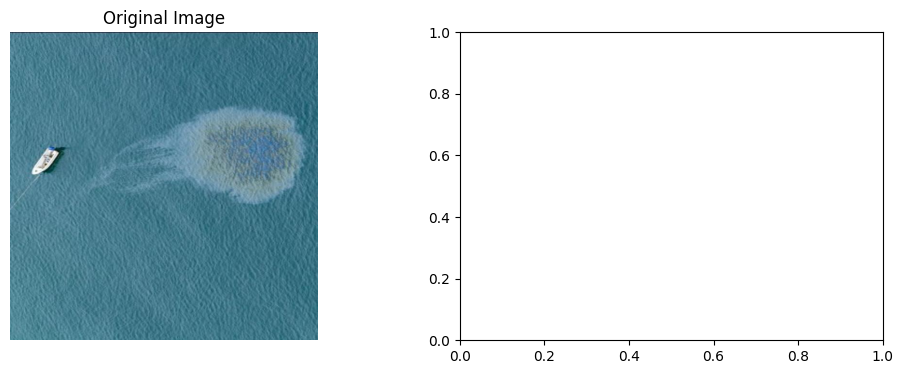

In [33]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_mask, cmap="hot")
plt.title("Raw Prediction Heatmap")
plt.colorbar()
plt.axis("off")

plt.show()

In [ ]:
thresholds = [0.05, 0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(18, 4))

for i, th in enumerate(thresholds):
    binary_mask = (pred_mask >= th).astype(np.uint8)

    plt.subplot(1, len(thresholds), i + 1)
    plt.imshow(binary_mask, cmap="gray")
    plt.title(f"Threshold {th}")
    plt.axis("off")

plt.show()